# 04 - XAI, drift temporal y analisis de errores

Este notebook estudia dos problematicas centrales del proyecto: explicabilidad y deriva temporal. Tambien analiza errores porque en dominio juridico no basta con decir que una metrica sube o baja; hay que entender que tipo de fallo se produce y que consecuencias puede tener.

La explicabilidad se trabaja en dos niveles:

- Global: pesos de terminos por articulo en la regresion logistica.
- Local: explicaciones de casos concretos con LIME cuando esta disponible.

La deriva se estudia comparando distribuciones y rendimiento entre particiones temporales. Si cambia el tipo de casos que llegan al sistema, el modelo puede degradarse aunque haya funcionado bien en entrenamiento.


In [1]:
from pathlib import Path
import json, sqlite3, re, random, math, warnings, sys, subprocess, importlib.util
from datetime import datetime, timezone
from uuid import uuid4
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

ROOT = Path.cwd().resolve()
DATA = ROOT / 'data'
RAW = DATA / 'raw'
INTERIM = DATA / 'interim'
PROCESSED = DATA / 'processed'
ARTIFACTS = ROOT / 'artifacts'
FIGURES = ARTIFACTS / 'figures'
METRICS = ARTIFACTS / 'metrics'
MODELS = ARTIFACTS / 'models'
INDICES = ARTIFACTS / 'indices'
REPORTS = ARTIFACTS / 'reports'
DB = INTERIM / 'metadata.db'
SCHEMA_PATH = ROOT / 'schema.sql'
for d in [RAW, INTERIM, PROCESSED, FIGURES, METRICS, MODELS, INDICES, REPORTS]:
    d.mkdir(parents=True, exist_ok=True)

def ensure_package(import_name, pip_name=None):
    if importlib.util.find_spec(import_name) is None:
        package = pip_name or import_name
        print(f'Instalando {package} en este kernel...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])

def dump_json(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)

def read_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)

print('ROOT =', ROOT)


ROOT = /Users/jordiblascolozano/Documents/proyecto aprendizaje avanzado


In [ ]:
# Celda de autosuficiencia: descarga y materializa el dataset si la base local no existe.
ensure_package('datasets')
from datasets import load_dataset

TASK = 'ecthr_task_b'
DATASET_NAME = 'lex_glue'
DATASET_SUBSET = 'ecthr_b'
CACHE_DIR = RAW / 'hf_cache'

TEXT_KEYS = ('text', 'facts', 'fact', 'document', 'content')
ID_KEYS = ('case_id', 'id', 'doc_id')
YEAR_KEYS = ('year', 'decision_year', 'judgment_year', 'date', 'decision_date', 'judgment_date')

def extract_text_segments(example):
    text_value = ''
    for key in TEXT_KEYS:
        if key in example and example[key] is not None:
            text_value = example[key]
            break
    if isinstance(text_value, str):
        cleaned = text_value.strip()
        return [cleaned] if cleaned else []
    if isinstance(text_value, list):
        return [str(x).strip() for x in text_value if isinstance(x, str) and str(x).strip()]
    return []

def parse_year(value):
    if isinstance(value, bool):
        return None
    if isinstance(value, int) and 1900 <= value <= 2100:
        return value
    if isinstance(value, float) and value.is_integer() and 1900 <= int(value) <= 2100:
        return int(value)
    if isinstance(value, str):
        m = re.search(r'(19|20)\d{2}', value)
        if m:
            return int(m.group(0))
    return None

def extract_year(example):
    for key in YEAR_KEYS:
        if key in example and example[key] is not None:
            y = parse_year(example[key])
            if y is not None:
                return y
    return None

def extract_label_ids(raw_labels, label_count=None):
    if isinstance(raw_labels, (int, float, bool)):
        v = int(raw_labels)
        return [v] if v >= 0 else []
    if not isinstance(raw_labels, (list, tuple)) or len(raw_labels) == 0:
        return []
    values = [int(v) for v in raw_labels if isinstance(v, (int, float, bool))]
    if label_count is not None and len(values) == label_count and set(values).issubset({0, 1}):
        return [i for i, v in enumerate(values) if v == 1]
    return sorted({v for v in values if v >= 0})

def build_case_id(example, task, split, row_idx):
    for key in ID_KEYS:
        if key in example and example[key] is not None:
            safe = re.sub(r'[^A-Za-z0-9_.-]+', '_', str(example[key])).strip('_')
            if safe:
                return f'{task}_{split}_{safe}'
    return f'{task}_{split}_{row_idx:06d}'

def build_case_record(example, task, split, row_idx):
    case_id = build_case_id(example, task, split, row_idx)
    segments = extract_text_segments(example)
    text_full = '\n\n'.join(segments)
    n_tokens = len(re.findall(r'\w+', text_full, flags=re.UNICODE))
    return {
        'case_id': case_id,
        'task': task,
        'split': split,
        'year': extract_year(example),
        'text_full': text_full,
        'n_paragraphs': len(segments),
        'n_tokens': n_tokens,
    }, segments

def extract_label_names(dataset_dict):
    split_name = 'train' if 'train' in dataset_dict else list(dataset_dict.keys())[0]
    features = getattr(dataset_dict[split_name], 'features', None)
    if not features or 'labels' not in features:
        return []
    label_feature = features['labels']
    if hasattr(label_feature, 'feature') and hasattr(label_feature.feature, 'names'):
        return [str(x) for x in label_feature.feature.names]
    if hasattr(label_feature, 'names'):
        return [str(x) for x in label_feature.names]
    return []

def metadata_db_ready(path=DB):
    if not Path(path).exists():
        return False
    try:
        conn = sqlite3.connect(path)
        n_cases = conn.execute('SELECT COUNT(*) FROM cases').fetchone()[0]
        n_labels = conn.execute('SELECT COUNT(*) FROM case_labels').fetchone()[0]
        conn.close()
        return n_cases > 0 and n_labels > 0
    except sqlite3.Error:
        return False

def ensure_metadata_db():
    if metadata_db_ready(DB):
        print(f'Dataset ya preparado en {DB}')
        return
    print('Descargando lex_glue/ecthr_b y creando metadata.db...')
    dataset = load_dataset(DATASET_NAME, DATASET_SUBSET, cache_dir=str(CACHE_DIR))
    label_names = extract_label_names(dataset)
    label_count = len(label_names) if label_names else None
    conn = sqlite3.connect(DB)
    conn.executescript(SCHEMA_PATH.read_text(encoding='utf-8'))
    case_rows, paragraph_rows, label_rows = [], [], []
    discovered_labels = set()
    split_counts = {}
    for split_name in dataset.keys():
        split_counts[split_name] = 0
        for row_idx, example in enumerate(dataset[split_name]):
            case_record, segments = build_case_record(example, task=TASK, split=split_name, row_idx=row_idx)
            case_rows.append(case_record)
            for pidx, paragraph in enumerate(segments):
                paragraph_rows.append({'case_id': case_record['case_id'], 'paragraph_idx': pidx, 'paragraph_text': paragraph})
            labels = extract_label_ids(example.get('labels'), label_count=label_count)
            for label_id in labels:
                discovered_labels.add(label_id)
                label_rows.append({'case_id': case_record['case_id'], 'article_id': str(label_id), 'value': 1})
            split_counts[split_name] += 1
    if label_names:
        article_rows = [{'article_id': str(i), 'article_code': name, 'description': ''} for i, name in enumerate(label_names)]
    else:
        article_rows = [{'article_id': str(i), 'article_code': f'article_{i}', 'description': ''} for i in sorted(discovered_labels)]
    with conn:
        conn.executemany('INSERT OR REPLACE INTO cases VALUES (:case_id, :task, :split, :year, :text_full, :n_paragraphs, :n_tokens)', case_rows)
        conn.executemany('INSERT OR REPLACE INTO case_paragraphs VALUES (:case_id, :paragraph_idx, :paragraph_text)', paragraph_rows)
        conn.executemany('INSERT OR REPLACE INTO articles VALUES (:article_id, :article_code, :description)', article_rows)
        conn.executemany('INSERT OR REPLACE INTO case_labels VALUES (:case_id, :article_id, :value)', label_rows)
        counts = {t: conn.execute(f'SELECT COUNT(*) FROM {t}').fetchone()[0] for t in ['cases','case_paragraphs','articles','case_labels','experiment_runs','predictions','explanations']}
    conn.close()
    report = {
        'stage': 'auto_ingestion_from_notebook',
        'timestamp_utc': datetime.now(timezone.utc).isoformat(),
        'dataset': {'name': DATASET_NAME, 'subset': DATASET_SUBSET, 'cache_dir': str(CACHE_DIR)},
        'task': TASK,
        'split_counts': split_counts,
        'inserted': {'articles': len(article_rows), 'cases': len(case_rows), 'case_paragraphs': len(paragraph_rows), 'case_labels': len(label_rows)},
        'table_counts': counts,
        'sqlite_path': str(DB),
    }
    dump_json(report, REPORTS / 'ingestion_status.json')
    print('Dataset preparado:', counts)

ensure_metadata_db()


In [3]:
from sklearn.metrics import f1_score, hamming_loss
import joblib


In [4]:
from dataclasses import dataclass, field
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

@dataclass
class OVRLogReg:
    c: float = 1.0
    max_iter: int = 2000
    solver: str = 'liblinear'
    random_state: int = 42
    n_labels: int | None = None
    constant_labels: dict = field(default_factory=dict)
    models: dict = field(default_factory=dict)
    def predict_scores(self, X):
        out = np.zeros((X.shape[0], self.n_labels), dtype=float)
        for j, v in self.constant_labels.items(): out[:, j] = float(v)
        for j, m in self.models.items(): out[:, j] = m.predict_proba(X)[:, 1]
        return out

@dataclass
class OVRLinearSVM:
    c: float = 1.0
    max_iter: int = 5000
    loss: str = 'squared_hinge'
    random_state: int = 42
    n_labels: int | None = None
    constant_labels: dict = field(default_factory=dict)
    models: dict = field(default_factory=dict)
    def predict_scores(self, X):
        out = np.zeros((X.shape[0], self.n_labels), dtype=float)
        for j, v in self.constant_labels.items(): out[:, j] = float(v)
        for j, m in self.models.items():
            margin = m.decision_function(X)
            out[:, j] = 1.0 / (1.0 + np.exp(-margin))
        return out


In [5]:
# Celda de autosuficiencia: entrena modelos y genera predicciones si faltan artefactos.
def load_classification_frames():
    conn = sqlite3.connect(DB)
    cases_df = pd.read_sql_query('SELECT case_id, split, text_full FROM cases ORDER BY case_id', conn)
    labels_df = pd.read_sql_query('SELECT case_id, article_id FROM case_labels WHERE value=1', conn)
    articles_df = pd.read_sql_query('SELECT * FROM articles ORDER BY CAST(article_id AS INTEGER)', conn)
    conn.close()
    article_ids = articles_df['article_id'].astype(str).tolist()
    article_to_idx = {a: i for i, a in enumerate(article_ids)}
    by_case = labels_df.groupby('case_id')['article_id'].apply(lambda s: [str(x) for x in s]).to_dict()
    Y = np.zeros((len(cases_df), len(article_ids)), dtype=int)
    for i, case_id in enumerate(cases_df['case_id']):
        for article_id in by_case.get(case_id, []):
            if article_id in article_to_idx:
                Y[i, article_to_idx[article_id]] = 1
    return cases_df, Y, articles_df

def fit_ovr_model(model_cls, X, Y, **kwargs):
    model = model_cls(**kwargs, n_labels=Y.shape[1])
    for j in range(Y.shape[1]):
        yj = Y[:, j]
        uniques = np.unique(yj)
        if len(uniques) < 2:
            model.constant_labels[j] = int(uniques[0]) if len(uniques) else 0
            continue
        if isinstance(model, OVRLogReg):
            clf = LogisticRegression(C=model.c, max_iter=model.max_iter, solver=model.solver, random_state=model.random_state)
        else:
            clf = LinearSVC(C=model.c, max_iter=model.max_iter, loss=model.loss, random_state=model.random_state)
        clf.fit(X, yj)
        model.models[j] = clf
    return model

def tune_thresholds(Y_val, scores_val):
    thresholds = np.full(Y_val.shape[1], 0.5, dtype=float)
    grid = np.linspace(0.10, 0.90, 17)
    for j in range(Y_val.shape[1]):
        best_t, best_f1 = 0.5, -1.0
        for t in grid:
            f1 = f1_score(Y_val[:, j], (scores_val[:, j] >= t).astype(int), zero_division=0)
            if f1 > best_f1:
                best_t, best_f1 = t, f1
        thresholds[j] = best_t
    return thresholds

def evaluate_multilabel(Y_true, Y_pred):
    return {
        'macro_f1': float(f1_score(Y_true, Y_pred, average='macro', zero_division=0)),
        'micro_f1': float(f1_score(Y_true, Y_pred, average='micro', zero_division=0)),
        'hamming_loss': float(hamming_loss(Y_true, Y_pred)),
    }

def classification_artifacts_ready(required):
    if not all(p.exists() for p in required):
        return False
    try:
        joblib.load(MODELS / 'notebook_tfidf_vectorizer.joblib')
        raw = joblib.load(MODELS / 'notebook_logreg_ovr.joblib')
        return isinstance(raw, dict) and 'models' in raw and (MODELS / 'notebook_thresholds.json').exists()
    except Exception:
        return False

def ensure_classification_artifacts():
    required = [
        MODELS / 'notebook_tfidf_vectorizer.joblib',
        MODELS / 'notebook_logreg_ovr.joblib',
        MODELS / 'notebook_svm_ovr.joblib',
        MODELS / 'notebook_thresholds.json',
    ]
    conn = sqlite3.connect(DB)
    pred_count = conn.execute("SELECT COUNT(*) FROM predictions WHERE run_id='notebook_threshold_tuned'").fetchone()[0]
    conn.close()
    if classification_artifacts_ready(required) and pred_count > 0:
        print('Modelos y predicciones ya preparados.')
        return

    print('Entrenando modelos TF-IDF + OVR dentro del notebook...')
    cases_df, Y, articles_df = load_classification_frames()
    train_mask = cases_df['split'].eq('train').to_numpy()
    val_mask = cases_df['split'].eq('validation').to_numpy()
    vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95, sublinear_tf=True, max_features=60000)
    X_train = vectorizer.fit_transform(cases_df.loc[train_mask, 'text_full'].fillna(''))
    X_all = vectorizer.transform(cases_df['text_full'].fillna(''))
    logreg_model = fit_ovr_model(OVRLogReg, X_train, Y[train_mask], c=1.0, max_iter=2000, solver='liblinear', random_state=SEED)
    svm_model = fit_ovr_model(OVRLinearSVM, X_train, Y[train_mask], c=1.0, max_iter=5000, loss='squared_hinge', random_state=SEED)
    scores_all = logreg_model.predict_scores(X_all)
    thresholds = tune_thresholds(Y[val_mask], scores_all[val_mask]) if val_mask.any() else np.full(Y.shape[1], 0.5)
    preds_all = (scores_all >= thresholds).astype(int)

    rows = []
    metrics_rows = []
    for split, idx in cases_df.groupby('split').groups.items():
        idx = np.array(list(idx), dtype=int)
        metrics = evaluate_multilabel(Y[idx], preds_all[idx])
        metrics_rows.append({'model': 'tfidf_logreg_threshold_tuned', 'split': split, 'n_cases': int(len(idx)), **metrics})
    for i, case_id in enumerate(cases_df['case_id']):
        rows.append({
            'run_id': 'notebook_threshold_tuned',
            'case_id': case_id,
            'y_true_json': json.dumps(Y[i].astype(int).tolist()),
            'y_pred_json': json.dumps(preds_all[i].astype(int).tolist()),
            'scores_json': json.dumps(scores_all[i].astype(float).tolist()),
        })

    joblib.dump(vectorizer, MODELS / 'notebook_tfidf_vectorizer.joblib')
    joblib.dump({
        'kind': 'OVRLogReg',
        'n_labels': logreg_model.n_labels,
        'constant_labels': logreg_model.constant_labels,
        'models': logreg_model.models,
    }, MODELS / 'notebook_logreg_ovr.joblib')
    joblib.dump({
        'kind': 'OVRLinearSVM',
        'n_labels': svm_model.n_labels,
        'constant_labels': svm_model.constant_labels,
        'models': svm_model.models,
    }, MODELS / 'notebook_svm_ovr.joblib')
    dump_json({'thresholds': thresholds.astype(float).tolist()}, MODELS / 'notebook_thresholds.json')

    metrics_df = pd.DataFrame(metrics_rows).sort_values(['model', 'split'])
    metrics_df.to_csv(METRICS / 'paper_classification_table.csv', index=False)
    ax = metrics_df.plot.bar(x='split', y='macro_f1', figsize=(7, 4), legend=False)
    ax.set_title('Macro-F1 por split')
    ax.set_ylabel('macro-F1')
    plt.tight_layout()
    plt.savefig(FIGURES / 'paper_classification_macro_f1.png', dpi=160)
    plt.close()

    conn = sqlite3.connect(DB)
    with conn:
        conn.execute("DELETE FROM predictions WHERE run_id='notebook_threshold_tuned'")
        conn.execute("DELETE FROM experiment_runs WHERE run_id='notebook_threshold_tuned'")
        conn.executemany('INSERT OR REPLACE INTO predictions VALUES (:run_id, :case_id, :y_true_json, :y_pred_json, :scores_json)', rows)
        conn.execute(
            'INSERT OR REPLACE INTO experiment_runs VALUES (?, ?, ?, ?, ?, ?, ?)',
            (
                'notebook_threshold_tuned',
                'classification_notebook',
                'tfidf_logreg_ovr',
                json.dumps({'vectorizer': 'tfidf', 'thresholds': 'validation_tuned'}),
                metrics_df.to_json(orient='records'),
                datetime.now(timezone.utc).isoformat(),
                None,
            ),
        )
    conn.close()
    print('Artefactos de clasificacion preparados:', metrics_df.to_dict(orient='records'))

ensure_classification_artifacts()


Entrenando modelos TF-IDF + OVR dentro del notebook...
Artefactos de clasificacion preparados: [{'model': 'tfidf_logreg_threshold_tuned', 'split': 'test', 'n_cases': 1000, 'macro_f1': 0.6720697396340237, 'micro_f1': 0.7363253856942497, 'hamming_loss': 0.0752}, {'model': 'tfidf_logreg_threshold_tuned', 'split': 'train', 'n_cases': 9000, 'macro_f1': 0.816110522014118, 'micro_f1': 0.876243093922652, 'hamming_loss': 0.037333333333333336}, {'model': 'tfidf_logreg_threshold_tuned', 'split': 'validation', 'n_cases': 1000, 'macro_f1': 0.6544848785666086, 'micro_f1': 0.7581560283687944, 'hamming_loss': 0.0682}]


## Ejemplo minimo: que significa un coeficiente en un modelo lineal

En un modelo lineal, cada termino tiene un peso para cada articulo. Un peso positivo empuja la prediccion hacia activar ese articulo; un peso negativo la aleja. Esto no es una sentencia juridica, pero si una pista auditable sobre el comportamiento del clasificador.


In [6]:
toy_coef_table = pd.DataFrame({
    'term': ['detention', 'fair trial', 'private life', 'family correspondence'],
    'article_5_weight': [1.8, 0.2, -0.4, -0.3],
    'article_8_weight': [-0.5, -0.2, 1.6, 1.4],
})
display(toy_coef_table)
print('Lectura: detention empuja mas el articulo 5; private life empuja mas el articulo 8.')


,term,article_5_weight,article_8_weight
0,detention,1.8,-0.5
1,fair trial,0.2,-0.2
2,private life,-0.4,1.6
3,family correspondence,-0.3,1.4


Lectura: detention empuja mas el articulo 5; private life empuja mas el articulo 8.


## Carga del modelo y de las predicciones

Este notebook reutiliza los artefactos generados por el notebook 02: vectorizador TF-IDF, modelos entrenados, umbrales y predicciones. No reentrena porque su objetivo es auditar el comportamiento del modelo ya seleccionado.

La separacion es importante para reproducibilidad: primero se fija el sistema predictivo, despues se analizan explicaciones, drift y errores sobre las mismas predicciones que se reportan en resultados.


In [7]:
def load_ovr_artifact(path, cls):
    raw = joblib.load(path)
    if isinstance(raw, cls):
        return raw
    if isinstance(raw, dict):
        model = cls(n_labels=raw.get('n_labels'))
        model.constant_labels = raw.get('constant_labels', {})
        model.models = raw.get('models', {})
        return model
    raise TypeError(f'Artefacto no reconocido: {path}')

vectorizer = joblib.load(MODELS / 'notebook_tfidf_vectorizer.joblib')
logreg = load_ovr_artifact(MODELS / 'notebook_logreg_ovr.joblib', OVRLogReg)
svm = load_ovr_artifact(MODELS / 'notebook_svm_ovr.joblib', OVRLinearSVM)
thresholds = np.array(read_json(MODELS / 'notebook_thresholds.json')['thresholds'])

conn = sqlite3.connect(DB)
articles = pd.read_sql_query('SELECT * FROM articles ORDER BY CAST(article_id AS INTEGER)', conn)
cases = pd.read_sql_query('SELECT case_id, split, year, n_tokens, text_full FROM cases', conn)
preds = pd.read_sql_query("SELECT p.*, c.split, c.year, c.n_tokens FROM predictions p JOIN cases c ON c.case_id=p.case_id WHERE p.run_id='notebook_threshold_tuned'", conn)
labels = pd.read_sql_query('SELECT cl.case_id, cl.article_id FROM case_labels cl JOIN cases c ON c.case_id = cl.case_id WHERE cl.value=1', conn)
conn.close()

def arr(s): return np.array(json.loads(s), dtype=float)
preds['y_true'] = preds['y_true_json'].map(arr)
preds['y_pred'] = preds['y_pred_json'].map(arr)
preds['scores'] = preds['scores_json'].map(arr)
print(preds.shape)


(11000, 11)


## XAI global por coeficientes

En modelos lineales, cada termino tiene un peso por articulo. Un peso positivo alto significa que, cuando ese termino aparece con fuerza TF-IDF, aumenta la puntuacion de ese articulo; un peso negativo la reduce.

Esta explicacion es global porque resume el comportamiento promedio del clasificador. Sirve para detectar senales razonables, como terminos juridicos asociados a un articulo, y tambien senales sospechosas, como nombres propios, artefactos de redaccion o palabras demasiado genericas.


In [8]:
feature_names = np.array(vectorizer.get_feature_names_out())
rows = []
for label_idx, model in logreg.models.items():
    coefs = model.coef_.ravel()
    top_pos = np.argsort(-coefs)[:15]
    top_neg = np.argsort(coefs)[:15]
    article_code = articles.loc[articles['article_id'].astype(str)==str(label_idx), 'article_code'].iloc[0]
    for rank, idx in enumerate(top_pos, 1):
        rows.append({'article_id': str(label_idx), 'article_code': article_code, 'direction': 'positive', 'rank': rank, 'term': feature_names[idx], 'weight': float(coefs[idx])})
    for rank, idx in enumerate(top_neg, 1):
        rows.append({'article_id': str(label_idx), 'article_code': article_code, 'direction': 'negative', 'rank': rank, 'term': feature_names[idx], 'weight': float(coefs[idx])})
global_terms = pd.DataFrame(rows)
global_terms.to_csv(METRICS / 'xai_global_terms.csv', index=False)
paper_xai = pd.DataFrame([{'n_global_labels': global_terms['article_id'].nunique(), 'n_local_explanations': 0, 'mean_abs_global_weight': float(global_terms['weight'].abs().mean()), 'mean_local_positive_prob': np.nan}])
global_terms.head(20)


,article_id,article_code,direction,rank,term,weight
0,0,2,positive,1,death,3.361481
1,0,2,positive,2,the death,2.095066
2,0,2,positive,3,son,1.958827
3,0,2,positive,4,died,1.786184
4,0,2,positive,5,autopsy,1.784902
5,0,2,positive,6,the investigation,1.758105
6,0,2,positive,7,investigation,1.687433
7,0,2,positive,8,death of,1.683749
8,0,2,positive,9,killed,1.484610
9,0,2,positive,10,shot,1.464257


## XAI local con LIME, si esta disponible

LIME explica una prediccion concreta perturbando el texto y entrenando un modelo local sencillo alrededor del caso. La pregunta que responde es: que palabras han pesado mas para esta etiqueta en este caso concreto.

La interpretacion debe ser prudente. LIME no demuestra causalidad juridica y puede ser sensible a la configuracion de muestras, pero es util para comunicar al usuario por que el sistema activo un articulo y para localizar falsos positivos o falsos negativos discutibles.


In [9]:
local_rows = []
try:
    ensure_package('lime')
    from lime.lime_text import LimeTextExplainer
    explainer = LimeTextExplainer(class_names=articles['article_code'].astype(str).tolist())
    def predict_proba_text(texts):
        X = vectorizer.transform(texts)
        return logreg.predict_scores(X)
    sample_cases = cases[cases['split']=='test'].head(5)
    for _, row in sample_cases.iterrows():
        probs = predict_proba_text([row['text_full']])[0]
        label_idx = int(np.argmax(probs))
        exp = explainer.explain_instance(row['text_full'], predict_proba_text, labels=[label_idx], num_features=10, num_samples=500)
        html_path = REPORTS / f"notebook_lime_{row['case_id']}_{label_idx}.html"
        html_path.write_text(exp.as_html(), encoding='utf-8')
        local_rows.append({'case_id': row['case_id'], 'label_idx': label_idx, 'article_code': articles.iloc[label_idx]['article_code'], 'positive_prob': float(probs[label_idx]), 'artifact_path': str(html_path)})
except Exception as e:
    print('LIME no ejecutado:', e)

lime_summary = pd.DataFrame(local_rows)
lime_summary.to_csv(METRICS / 'xai_lime_summary.csv', index=False)
if len(lime_summary):
    paper_xai.loc[0, 'n_local_explanations'] = len(lime_summary)
    paper_xai.loc[0, 'mean_local_positive_prob'] = float(lime_summary['positive_prob'].mean())
paper_xai.to_csv(METRICS / 'paper_xai_table.csv', index=False)
paper_xai


Instalando lime en este kernel...



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip3.11 install --upgrade pip


,n_global_labels,n_local_explanations,mean_abs_global_weight,mean_local_positive_prob
0,10,5,1.372111,0.736374


## Ejemplo minimo: explicacion local por perturbacion

Una explicacion local intenta responder por que se activo una etiqueta en un caso concreto. El ejemplo siguiente entrena un clasificador pequeno y compara la probabilidad del texto original con la probabilidad despues de retirar una palabra clave.


In [10]:
local_texts = [
    'detention fair trial applicant',
    'detention prison arrest',
    'private life correspondence family',
    'family home private life',
]
local_y = np.array([1, 1, 0, 0])
local_vec = TfidfVectorizer(ngram_range=(1, 2), min_df=1)
local_X = local_vec.fit_transform(local_texts)
local_model = LogisticRegression(solver='liblinear', random_state=SEED).fit(local_X, local_y)

full_text = 'detention and fair trial complaint by applicant'
without_detention = full_text.replace('detention', '')
local_scores = pd.DataFrame({
    'version': ['texto_original', 'sin_detention'],
    'score_articulo_demo': local_model.predict_proba(local_vec.transform([full_text, without_detention]))[:, 1],
})
display(local_scores)


,version,score_articulo_demo
0,texto_original,0.599410
1,sin_detention,0.581358


## Drift de datos y rendimiento

El drift se mide en dos planos. Primero, drift de datos: cambios en longitud documental y distribucion de etiquetas respecto a `train`. Segundo, drift de rendimiento: macro-F1, micro-F1 y Hamming loss por split o anio.

La divergencia Jensen-Shannon se usa para comparar distribuciones de etiquetas porque es simetrica y acotada. Un valor mayor indica que el perfil de articulos de un split se aleja mas del entrenamiento, lo que puede explicar degradacion de rendimiento.


In [11]:
def stack_col(df, col):
    return np.vstack(df[col].to_numpy()) if len(df) else np.empty((0, len(articles)))

def perf(df):
    yt = stack_col(df, 'y_true').astype(int)
    yp = stack_col(df, 'y_pred').astype(int)
    return {'macro_f1': float(f1_score(yt, yp, average='macro', zero_division=0)), 'micro_f1': float(f1_score(yt, yp, average='micro', zero_division=0)), 'hamming_loss': float(hamming_loss(yt, yp)), 'n_cases': int(len(df))}

perf_rows = []
for split, g in preds.groupby('split'):
    m = perf(g); m['split'] = split; perf_rows.append(m)
perf_split = pd.DataFrame(perf_rows)
perf_split.to_csv(METRICS / 'drift_performance_by_split.csv', index=False)

# shift de etiquetas entre train y validation/test
train_label_counts = labels.merge(cases[['case_id','split']], on='case_id')
train_dist = train_label_counts[train_label_counts['split']=='train']['article_id'].value_counts(normalize=True)
shift_rows = []
for split in ['validation','test']:
    dist = train_label_counts[train_label_counts['split']==split]['article_id'].value_counts(normalize=True)
    all_idx = sorted(set(train_dist.index) | set(dist.index), key=lambda x: int(x) if str(x).isdigit() else x)
    p = np.array([train_dist.get(i, 0.0) for i in all_idx]) + 1e-12
    q = np.array([dist.get(i, 0.0) for i in all_idx]) + 1e-12
    p, q = p/p.sum(), q/q.sum()
    m = 0.5*(p+q)
    js = 0.5*np.sum(p*np.log2(p/m)) + 0.5*np.sum(q*np.log2(q/m))
    l1 = np.sum(np.abs(p-q))
    cos = float(np.dot(p,q)/(np.linalg.norm(p)*np.linalg.norm(q)))
    shift_rows.append({'target_split': split, 'js_divergence': float(js), 'l1_distance': float(l1), 'cosine_similarity': cos})
shift = pd.DataFrame(shift_rows)
shift.to_csv(METRICS / 'drift_label_shift_by_split.csv', index=False)

base = perf_split[perf_split['split']=='validation'].iloc[0]
drift_table = shift.copy()
for metric in ['macro_f1','micro_f1','hamming_loss']:
    vals = []
    for s in drift_table['target_split']:
        cur = perf_split[perf_split['split']==s].iloc[0]
        vals.append(float(cur[metric] - base[metric]))
    drift_table[f'delta_{metric}'] = vals
drift_table.to_csv(METRICS / 'paper_drift_table.csv', index=False)
drift_table


,target_split,js_divergence,l1_distance,cosine_similarity,delta_macro_f1,delta_micro_f1,delta_hamming_loss
0,validation,0.017336,0.278045,0.958946,0.000000,0.000000,0.000
1,test,0.025531,0.320362,0.950533,0.017585,-0.021831,0.007


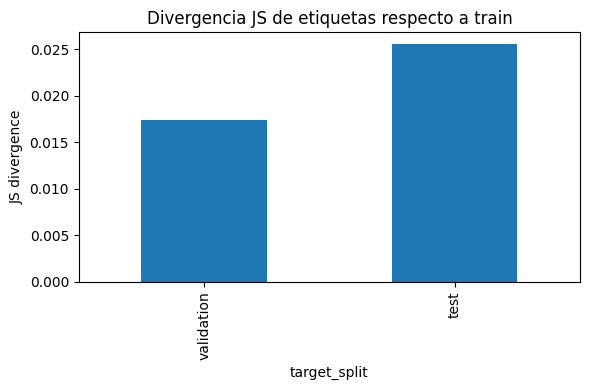

In [12]:
ax = drift_table.plot.bar(x='target_split', y='js_divergence', legend=False, figsize=(6,4))
ax.set_title('Divergencia JS de etiquetas respecto a train')
ax.set_ylabel('JS divergence')
plt.tight_layout()
plt.savefig(FIGURES / 'paper_drift_js_divergence.png', dpi=160)


## Ejemplo minimo: drift de etiquetas

El drift de etiquetas mide si cambia la distribucion de articulos entre entrenamiento y evaluacion. En el ejemplo, `test` tiene mas peso del articulo 8 que `train`, lo que puede afectar a un modelo que aprendio principalmente patrones de articulos 5 y 6.


In [13]:
from scipy.spatial.distance import jensenshannon

train_label_distribution = np.array([0.50, 0.35, 0.15])
test_label_distribution = np.array([0.30, 0.30, 0.40])
js_distance = jensenshannon(train_label_distribution, test_label_distribution)

pd.DataFrame({
    'article': ['art_5', 'art_6', 'art_8'],
    'train_distribution': train_label_distribution,
    'test_distribution': test_label_distribution,
    'absolute_shift': np.abs(train_label_distribution - test_label_distribution),
}).assign(js_distance=js_distance)


,article,train_distribution,test_distribution,absolute_shift,js_distance
0,art_5,0.50,0.3,0.20,0.207544
1,art_6,0.35,0.3,0.05,0.207544
2,art_8,0.15,0.4,0.25,0.207544


## Analisis de errores

El analisis de errores traduce las metricas en casos auditables. Para cada caso se calculan falsos positivos, falsos negativos y patrones de error. Esto permite responder preguntas practicas: que articulos se omiten, cuales se predicen de mas y en que splits aparecen mas fallos.

En la discusion del informe, un falso negativo puede ser mas grave que un falso positivo si hace que un abogado no investigue un articulo relevante. Un falso positivo, en cambio, puede consumir tiempo o anclar la estrategia hacia precedentes poco pertinentes. Esa diferencia de impacto es clave para conectar ML con el dominio juridico.


In [14]:
err_rows = []
for _, r in preds.iterrows():
    yt = r['y_true'].astype(int); yp = r['y_pred'].astype(int)
    fp = int(((yp==1) & (yt==0)).sum())
    fn = int(((yp==0) & (yt==1)).sum())
    tp = int(((yp==1) & (yt==1)).sum())
    err_rows.append({'case_id': r['case_id'], 'split': r['split'], 'tp': tp, 'fp': fp, 'fn': fn, 'n_errors': fp+fn, 'n_true': int(yt.sum()), 'n_pred': int(yp.sum())})
errors = pd.DataFrame(err_rows)
errors.to_csv(METRICS / 'error_analysis_cases.csv', index=False)
patterns = errors.groupby(['split','fp','fn']).size().reset_index(name='n_cases').sort_values(['split','n_cases'], ascending=[True,False])
patterns.to_csv(METRICS / 'error_analysis_patterns.csv', index=False)
patterns.head(20).to_csv(METRICS / 'paper_error_pattern_table.csv', index=False)
summary = errors.groupby('split')[['tp','fp','fn','n_errors']].mean().reset_index()
summary.to_csv(METRICS / 'paper_error_split_table.csv', index=False)
patterns.head(20)


,split,fp,fn,n_cases
0,test,0,0,462
6,test,1,0,194
1,test,0,1,167
7,test,1,1,85
2,test,0,2,38
10,test,2,0,26
8,test,1,2,8
11,test,2,1,6
3,test,0,3,4
9,test,1,3,3


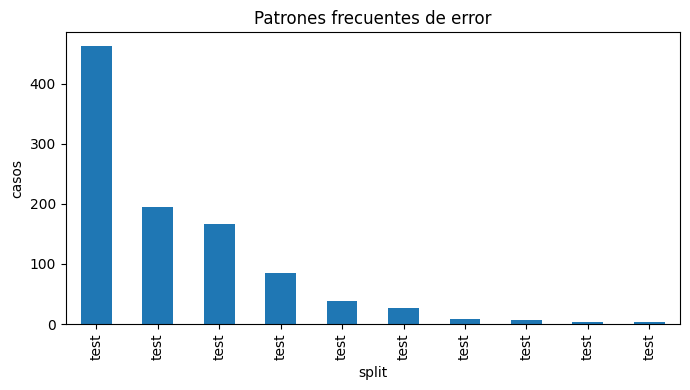

In [15]:
ax = patterns.head(10).plot.bar(x='split', y='n_cases', figsize=(7,4), legend=False)
ax.set_title('Patrones frecuentes de error')
ax.set_ylabel('casos')
plt.tight_layout()
plt.savefig(FIGURES / 'paper_error_patterns.png', dpi=160)


## Ejemplo minimo: falsos positivos y falsos negativos

En multietiqueta, un mismo caso puede tener aciertos y errores a la vez. Un falso negativo significa que el articulo era relevante y no se predijo; un falso positivo significa que el sistema sugirio un articulo no anotado. En uso juridico, ambos tienen costes distintos.


In [16]:
y_true_error_demo = np.array([[1, 0, 1]])
y_pred_error_demo = np.array([[1, 1, 0]])
article_names_demo = np.array(['art_5', 'art_6', 'art_8'])

pd.DataFrame({
    'article': article_names_demo,
    'y_true': y_true_error_demo.ravel(),
    'y_pred': y_pred_error_demo.ravel(),
    'error_type': np.where(
        (y_true_error_demo.ravel() == 0) & (y_pred_error_demo.ravel() == 1), 'false_positive',
        np.where((y_true_error_demo.ravel() == 1) & (y_pred_error_demo.ravel() == 0), 'false_negative', 'correct')
    )
})


,article,y_true,y_pred,error_type
0,art_5,1,1,correct
1,art_6,0,1,false_positive
2,art_8,1,0,false_negative
